In [1]:
# ============================================
# XGBoost + AUC-based Permutation Importance
# Dynamic 2/3 Feature Selection Rule
# ============================================
%pip install numpy pandas scikit-learn matplotlib seaborn xgboost
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

from xgboost import XGBClassifier

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================
# 1. Load Dataset
# ============================================
df = pd.read_csv('pokemon_stats_2025_copy.csv')

# 2. สร้าง Target Class (is_legendary) 
legendary_ids = [144, 145, 146, 150, 151, 243, 244, 245, 249, 250]
df['is_legendary'] = df['pokedex_id'].apply(lambda x: 1 if x in legendary_ids else 0)

# ============================================
# 3. จัดการ Missing Value และเตรียมข้อมูล
# ============================================
# แก้ 'None' เป็น 'none' ให้ตรงกับ dictionary
df['type_2'] = df['type_2'].fillna('none')

# 4. แปลงข้อมูลตัวอักษรเป็นตัวเลข (Label Encoding)
type_mapping = {
    'none': 0, 'bug': 1, 'dark': 2, 'dragon': 3, 'electric': 4, 
    'fairy': 5, 'fighting': 6, 'fire': 7, 'flying': 8, 'ghost': 9, 
    'grass': 10, 'ground': 11, 'ice': 12, 'normal': 13, 'poison': 14, 
    'psychic': 15, 'rock': 16, 'steel': 17, 'water': 18
}

# 5. ทำการเปลี่ยน (Map) ทีละคอลัมน์
df['type_1_encoded'] = df['type_1'].map(type_mapping)
df['type_2_encoded'] = df['type_2'].map(type_mapping)

# 6. ตัดคอลัมน์ที่ไม่จำเป็นทิ้ง (Feature Drop)
df_cleaned = df.drop(columns=['pokedex_id', 'name', 'type_1', 'type_2', 'base_experience'])

# เช็คข้อมูลเบื้องต้นหลัง Clean (แก้ไข Syntax ที่ผิดให้แล้ว)
print("--- ข้อมูลหลังทำความสะอาด ---")
print(df_cleaned.head())

# ============================================
# 4. กำหนด Feature & Target และทำ Scaling
# ============================================
# 7. กำหนด Features (X) และ Target (y)
X = df_cleaned.drop(columns=['is_legendary'])
y = df_cleaned['is_legendary']

# 8. ปรับสเกลข้อมูล (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\n--- เตรียมข้อมูลเสร็จสิ้น! ข้อมูลพร้อมนำไปใช้ ---")
print(f"จำนวน Features: {X_scaled_df.shape[1]}")
print(f"จำนวนข้อมูล (แถว): {X_scaled_df.shape[0]}")
# แสดงผล 5 แถวแรกของข้อมูลที่พร้อมนำไปเข้า Model
X_scaled_df.head()

--- ข้อมูลหลังทำความสะอาด ---
   height  weight  hp  attack  defense  special_attack  special_defense  \
0       7      69  45      49       49              65               65   
1      10     130  60      62       63              80               80   
2      20    1000  80      82       83             100              100   
3       6      85  39      52       43              60               50   
4      11     190  58      64       58              80               65   

   speed  is_legendary  type_1_encoded  type_2_encoded  
0     45             0              10              14  
1     60             0              10              14  
2     80             0              10              14  
3     65             0               7               0  
4     80             0               7               0  

--- เตรียมข้อมูลเสร็จสิ้น! ข้อมูลพร้อมนำไปใช้ ---
จำนวน Features: 10
จำนวนข้อมูล (แถว): 250


,height,weight,hp,attack,defense,special_attack,special_defense,speed,type_1_encoded,type_2_encoded
0,-0.479713,-0.656732,-0.732699,-0.800647,-0.647963,-0.034886,-0.125947,-0.766760,-0.174926,1.502420
1,-0.182616,-0.557760,-0.227993,-0.326330,-0.187107,0.514790,0.421332,-0.215927,-0.174926,1.502420
2,0.807708,0.853806,0.444949,0.403388,0.471258,1.247692,1.151038,0.518518,-0.174926,1.502420
3,-0.578745,-0.630772,-0.934581,-0.691189,-0.845472,-0.218112,-0.673226,-0.032316,-0.721571,-0.831566
4,-0.083583,-0.460411,-0.295287,-0.253358,-0.351699,0.514790,-0.125947,0.518518,-0.721571,-0.831566


In [3]:
# ============================================
# 2. Train / Validation Split
# ============================================

# ใช้ X_scaled_df ที่ผ่านการทำ Standardization มาแล้วจากขั้นตอนก่อนหน้า
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled_df, y, test_size=0.3, random_state=42, stratify=y
)

print(f"จำนวนข้อมูล Train: {X_train.shape[0]} ตัวอย่าง")
print(f"จำนวนข้อมูล Validation: {X_val.shape[0]} ตัวอย่าง")

จำนวนข้อมูล Train: 175 ตัวอย่าง
จำนวนข้อมูล Validation: 75 ตัวอย่าง


In [4]:
# ============================================
# 3. Train Initial XGBoost Model
# ============================================

model_full = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

model_full.fit(X_train, y_train)

baseline_auc = roc_auc_score(
    y_val,
    model_full.predict_proba(X_val)[:, 1]
)

print("\nBaseline AUC (All Features):", round(baseline_auc, 4))


Baseline AUC (All Features): 0.9352


In [5]:
# ============================================
# 4. Tree-based Ranking (GAIN)
# ============================================

booster = model_full.get_booster()
score_dict = booster.get_score(importance_type="gain")

tree_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": [score_dict.get(f, 0) for f in X.columns]
}).sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

In [6]:
# ============================================
# 5. Dynamic 2/3 Feature Selection
# ============================================

total_features = X.shape[1]
k = int(np.ceil((2/3) * total_features))

selected_features = tree_importance.head(k)["feature"].tolist()

print(f"\nUsing 2/3 Rule → Selecting top {k} features out of {total_features}")


Using 2/3 Rule → Selecting top 7 features out of 10


In [7]:
# ============================================
# 6. Retrain Model with Selected Features
# ============================================

model_selected = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

model_selected.fit(X_train[selected_features], y_train)

selected_auc = roc_auc_score(
    y_val,
    model_selected.predict_proba(X_val[selected_features])[:, 1]
)

print("AUC after retraining (2/3 features):", round(selected_auc, 4))


AUC after retraining (2/3 features): 0.9444


In [8]:
# ============================================
# 7. AUC-Based Permutation Importance
# ============================================

perm = permutation_importance(
    model_selected,
    X_val[selected_features],
    y_val,
    n_repeats=50,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": selected_features,
    "auc_importance_mean": perm.importances_mean,
    "auc_importance_std": perm.importances_std
}).sort_values(
    by="auc_importance_mean",
    ascending=False
).reset_index(drop=True)

importance_df["rank"] = importance_df.index + 1

importance_df = importance_df[[
    "rank",
    "feature",
    "auc_importance_mean",
    "auc_importance_std"
]]

# ============================================
# 8. Display Ranking
# ============================================

print("\n======================================")
print("AUC-Based Permutation Importance Ranking")
print("======================================")
print(importance_df)
print("\n\n")


AUC-Based Permutation Importance Ranking
   rank          feature  auc_importance_mean  auc_importance_std
0     1               hp             0.080833            0.032051
1     2          defense             0.041574            0.013780
2     3           height             0.024074            0.014012
3     4            speed             0.013611            0.025949
4     5  special_defense             0.005741            0.004589
5     6   special_attack             0.002222            0.018524
6     7           attack             0.001389            0.012905





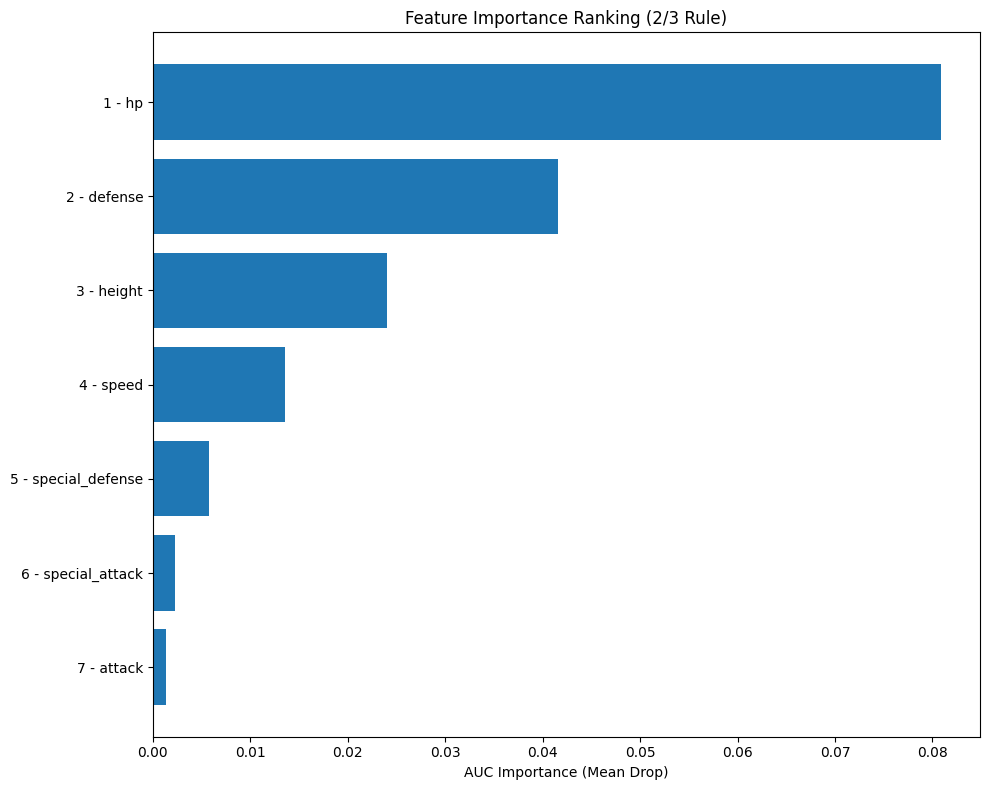


Pipeline Completed Successfully (2/3 Rule)


In [9]:
# ============================================
# 9. Plot Importance
# ============================================

plt.figure(figsize=(10, 8))

labels = importance_df["rank"].astype(str) + " - " + importance_df["feature"]

plt.barh(labels, importance_df["auc_importance_mean"])
plt.xlabel("AUC Importance (Mean Drop)")
plt.title("Feature Importance Ranking (2/3 Rule)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nPipeline Completed Successfully (2/3 Rule)")


In [10]:
# ============================================
# บันทึกข้อมูลเพื่อส่งต่อไปยัง Feature Selection
# ============================================

# บันทึก DataFrame ที่ผ่านการ Clean และตัดตัวแปรเจ้าปัญหาทิ้งแล้ว
df_cleaned.to_csv('pokemon_cleaned_for_selection.csv', index=False)

print("บันทึกไฟล์ pokemon_cleaned_for_selection.csv สำเร็จ! พร้อมนำไปใช้ในไฟล์ต่อไป")

บันทึกไฟล์ pokemon_cleaned_for_selection.csv สำเร็จ! พร้อมนำไปใช้ในไฟล์ต่อไป
